In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
train_df = pd.read_parquet("Data\merged_training.parquet")
test_df = pd.read_parquet("Data\merged_testing.parquet")

In [4]:
train_df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,49,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
1,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
2,17,1,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
4,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP


In [5]:
test_df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,48,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,1,2,0,2896.0,0.0,1448.0,1448.0,1448.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS


In [6]:
corr_matrix = train_df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Features to drop:", to_drop)

Features to drop: ['Bwd Packets Length Total', 'Fwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'RST Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Fwd Act Data Packets', 'Idle Mean', 'Idle Max', 'Idle Min']


In [7]:
train_df = train_df.drop(columns=to_drop)
test_df = test_df.drop(columns=to_drop)

In [8]:
train_df["Label"].value_counts()

Label
Syn        48840
Benign     46427
UDP        18090
MSSQL       8523
LDAP        1906
Portmap      685
NetBIOS      644
UDPLag        55
Name: count, dtype: int64

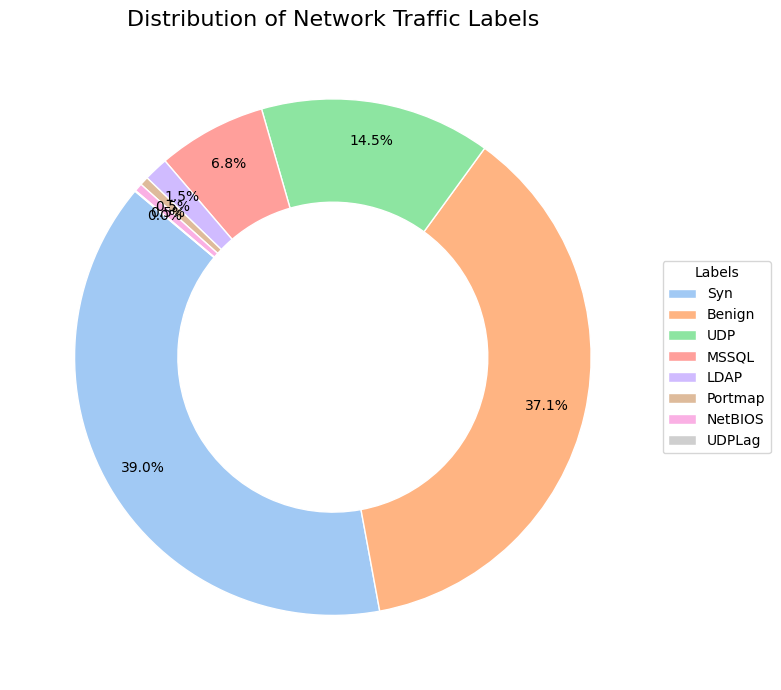

In [11]:
counts = train_df["Label"].value_counts()
plt.figure(figsize=(10, 7))
colors = sns.color_palette('pastel')[0:len(counts)]
wedges, texts, autotexts = plt.pie(counts, 
                                   labels=None,        # Remove direct labels to avoid overlap
                                   autopct='%1.1f%%', 
                                   startangle=140, 
                                   colors=colors,
                                   pctdistance=0.85,
                                   wedgeprops=dict(width=0.4, edgecolor='white')) # Donut effect

plt.legend(wedges, counts.index, title="Labels", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Distribution of Network Traffic Labels', fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
le = LabelEncoder()
train_df['Label_encoded'] = le.fit_transform(train_df['Label'])
print(train_df[['Label','Label_encoded']].head())

     Label  Label_encoded
0  NetBIOS              3
1     LDAP              1
2  NetBIOS              3
3     LDAP              1
4     LDAP              1


In [13]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'Benign': np.int64(0), 'LDAP': np.int64(1), 'MSSQL': np.int64(2), 'NetBIOS': np.int64(3), 'Portmap': np.int64(4), 'Syn': np.int64(5), 'UDP': np.int64(6), 'UDPLag': np.int64(7)}


In [18]:
# Features
X = train_df.drop(columns=['Label','Label_encoded'])

In [19]:
# Target
y = train_df['Label_encoded']

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from imblearn.over_sampling import SMOTE

In [21]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [22]:
scaler = StandardScaler()

In [23]:
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_val = scaler.transform(X_val)

In [24]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_resampled, y_train_resampled)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred = rf.predict(X_val)

In [26]:
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9841415674682432


In [27]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9285
           1       0.89      0.96      0.92       381
           2       0.95      0.93      0.94      1705
           3       0.59      0.75      0.66       129
           4       0.43      0.39      0.41       137
           5       1.00      1.00      1.00      9768
           6       0.98      0.97      0.98      3618
           7       0.07      0.27      0.11        11

    accuracy                           0.98     25034
   macro avg       0.74      0.78      0.75     25034
weighted avg       0.99      0.98      0.98     25034



In [28]:
cm = confusion_matrix(y_val, y_pred)

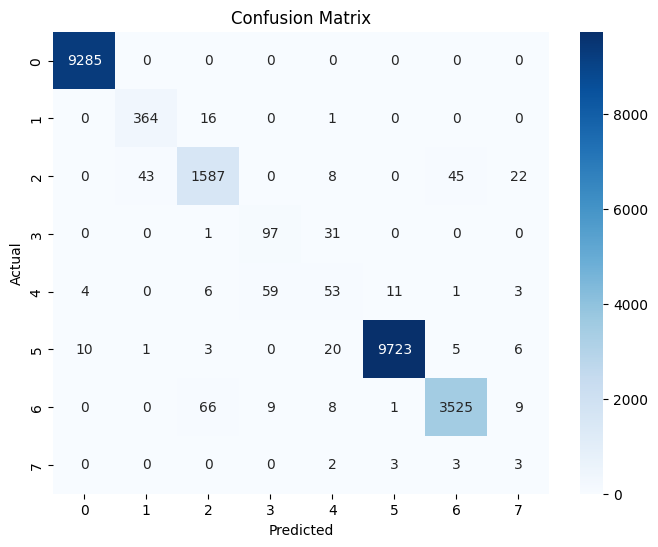

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


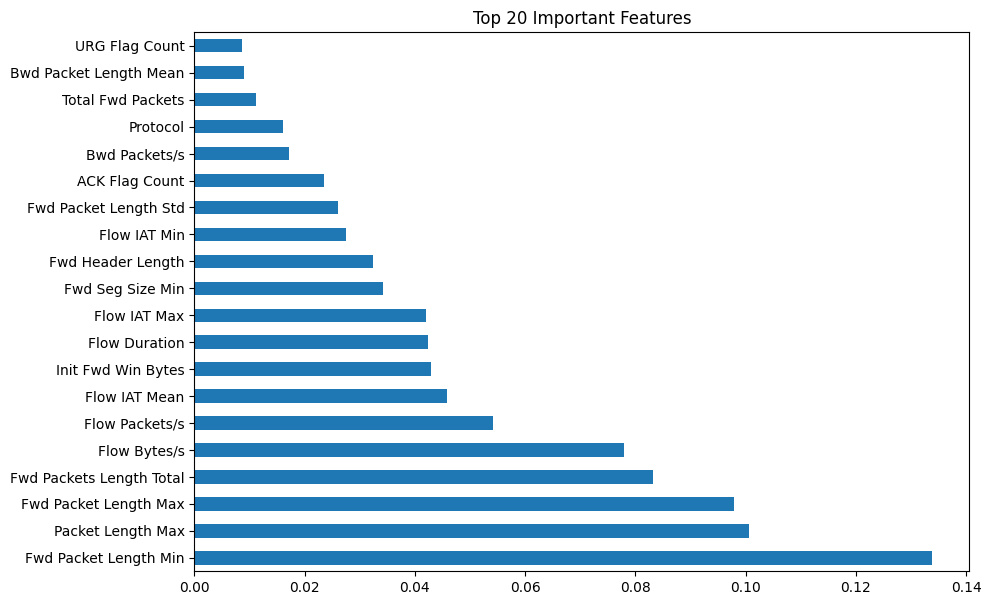

In [31]:
importances = rf.feature_importances_
feat_names = X.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
feat_imp.head(20).plot(kind='barh', figsize=(10,7))
plt.title("Top 20 Important Features")
plt.show()